# 뇌졸중(Stroke) 예측 모델

Kaggle의 Healthcare Dataset을 활용해서 뇌졸중 발생 여부를 예측하는 분류 모델을 만들어봤습니다.  
데이터 불균형 문제를 SMOTE로 해결하고, 여러 모델의 성능을 비교했습니다.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

from scipy import stats

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, roc_auc_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic']
installed_fonts = {font.name for font in fm.fontManager.ttflist}
for font in font_candidates:
    if font in installed_fonts:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False

df_raw = pd.read_csv('healthcare-dataset-stroke-data.csv')
print(df_raw.shape)
df_raw.head(3)

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1


## 1. 타겟 분포 확인

먼저 뇌졸중 발생 비율을 확인해봤습니다.

In [15]:
print('타겟 분포:')
print(df_raw['stroke'].value_counts())

print('\n타겟 비율:')
print(df_raw['stroke'].value_counts(normalize=True).round(4))

타겟 분포:
stroke
0    4861
1     249
Name: count, dtype: int64

타겟 비율:
stroke
0    0.9513
1    0.0487
Name: proportion, dtype: float64


## 2. 데이터 전처리

In [16]:
df = df_raw.copy()

# 18세 이하 제거
df = df[df['age'] > 18].copy()

# 컬럼명 통일 및 id 제거
df = df.rename(columns={'Residence_type': 'residence_type'})
df = df.drop(columns=['id'])

print('전처리 전 데이터 크기:', df.shape)
print('bmi 결측치 수:', df['bmi'].isna().sum())

전처리 전 데이터 크기: (4194, 11)
bmi 결측치 수: 180


## 3. 이상치 제거

IQR 방법을 사용해서 극단적인 이상치를 제거했습니다. 기준은 Q3 + 3.0 * IQR로 잡았습니다.

In [17]:
num_outlier_cols = ['avg_glucose_level', 'bmi']

Q1 = df[num_outlier_cols].quantile(0.25)
Q3 = df[num_outlier_cols].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 3.0 * IQR

mask = (
    (df['avg_glucose_level'] <= upper['avg_glucose_level']) &
    (df['bmi'].isna() | (df['bmi'] <= upper['bmi']))
)

df = df[mask].copy()

print('이상치 제거 후 데이터 크기:', df.shape)
print('이상치 제거 후 bmi 결측치 수:', df['bmi'].isna().sum())
print('\n타겟 분포:')
print(df['stroke'].value_counts())

이상치 제거 후 데이터 크기: (4085, 11)
이상치 제거 후 bmi 결측치 수: 170

타겟 분포:
stroke
0    3854
1     231
Name: count, dtype: int64


## 4. 탐색적 데이터 분석 (EDA)

### 4-1. 수치형 변수 분포

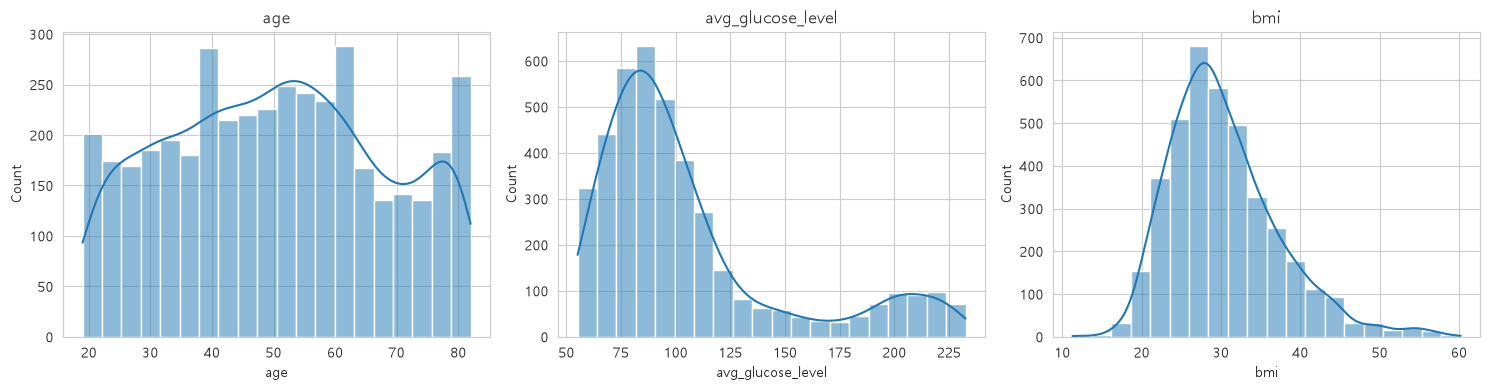

In [18]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, kde=True, bins=20, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### 4-2. 범주형 변수 분포

C:\Users\jmjeo\AppData\Local\Temp\ipykernel_40584\1637745855.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


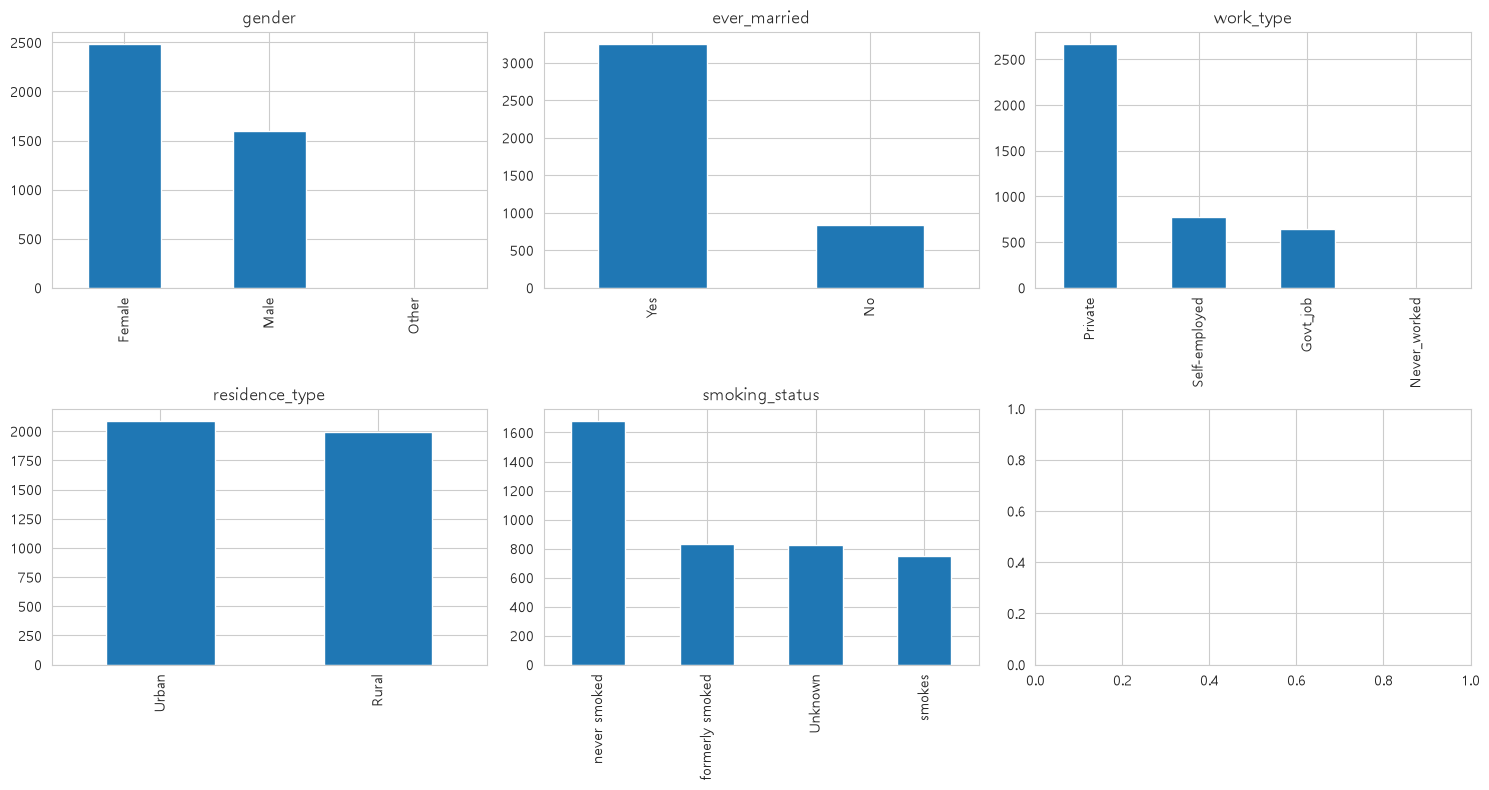

In [19]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### 4-3. 뇌졸중 여부별 비교

stroke=0(정상)과 stroke=1(뇌졸중)을 비교해서 어떤 변수가 뇌졸중과 관련이 있는지 확인했습니다.

C:\Users\jmjeo\AppData\Local\Temp\ipykernel_40584\788824409.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stroke', y=col, ax=ax, palette='Set2')
C:\Users\jmjeo\AppData\Local\Temp\ipykernel_40584\788824409.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stroke', y=col, ax=ax, palette='Set2')
C:\Users\jmjeo\AppData\Local\Temp\ipykernel_40584\788824409.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stroke', y=col, ax=ax, palette='Set2')


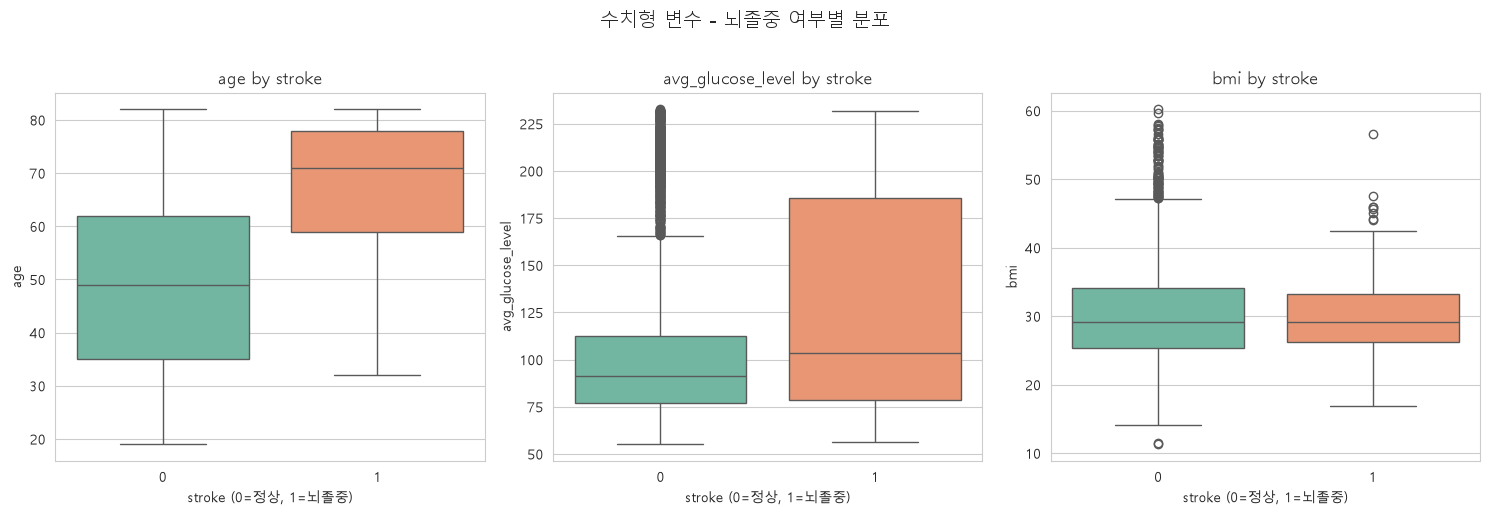

In [20]:
# 수치형 변수: stroke 여부별 boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='stroke', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col} by stroke')
    ax.set_xlabel('stroke (0=정상, 1=뇌졸중)')

plt.suptitle('수치형 변수 - 뇌졸중 여부별 분포', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

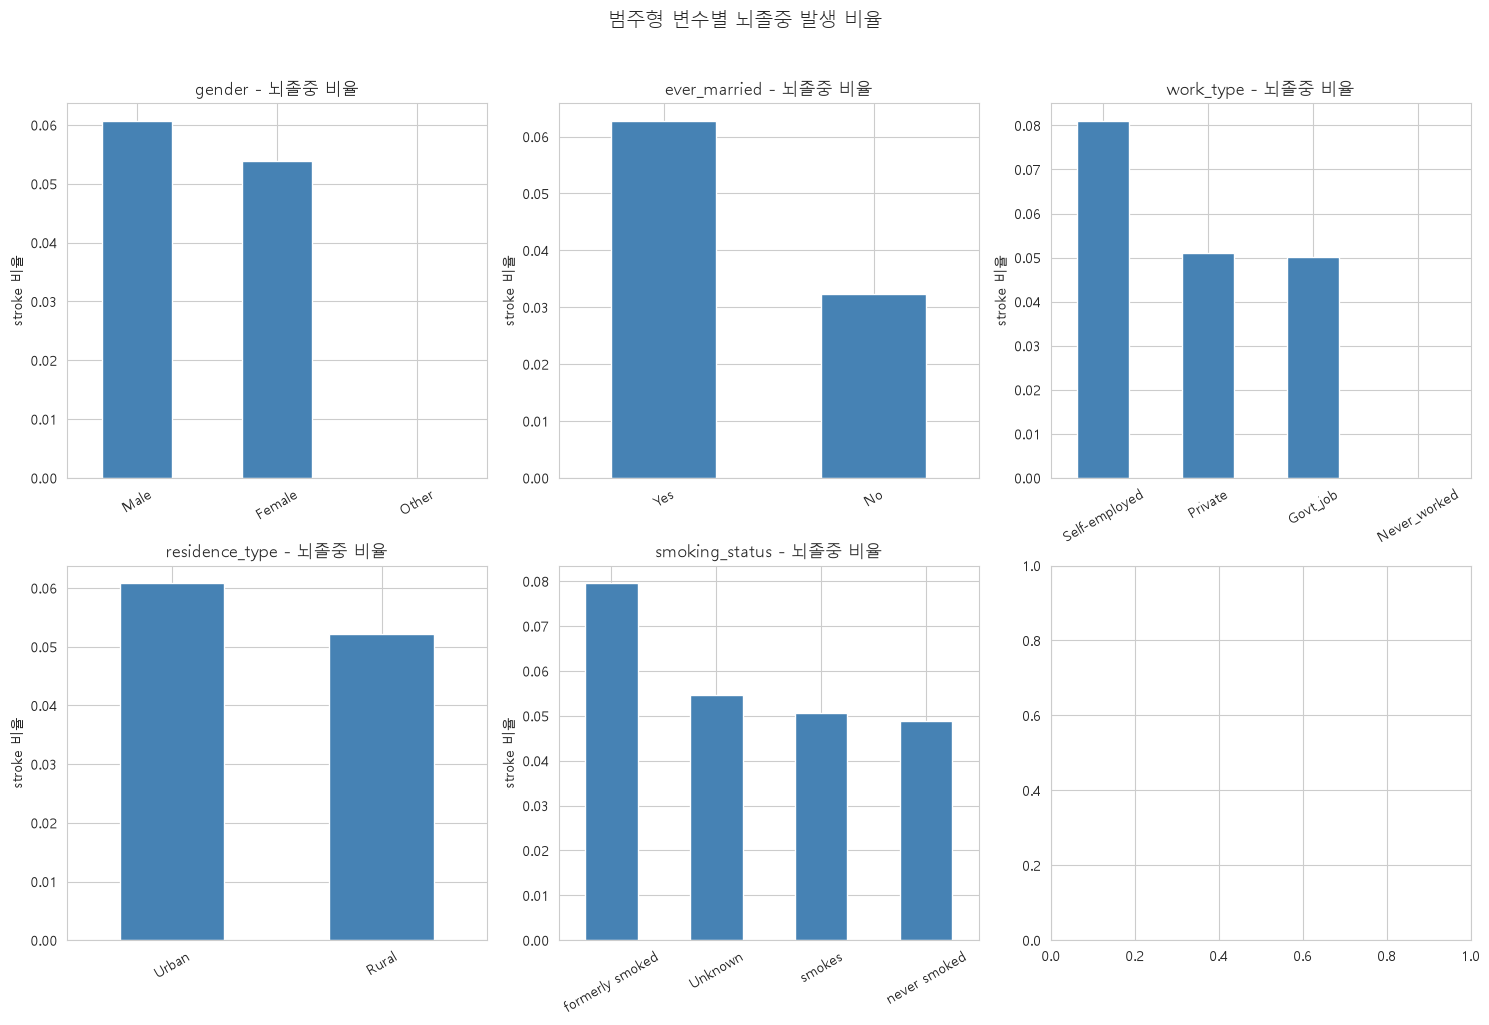

In [21]:
# 범주형 변수: 각 카테고리별 뇌졸중 비율
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    stroke_rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False)
    stroke_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} - 뇌졸중 비율')
    ax.set_ylabel('stroke 비율')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('범주형 변수별 뇌졸중 발생 비율', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

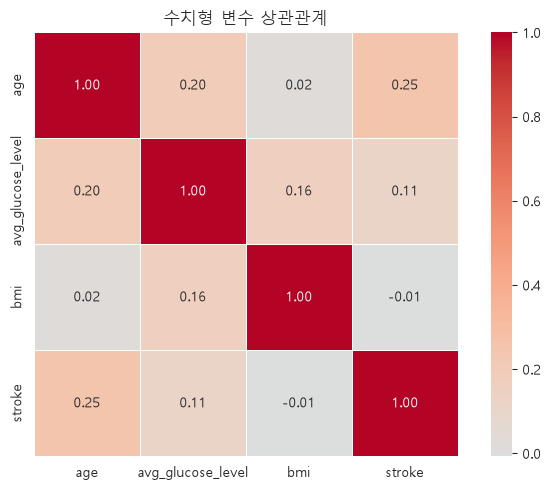

In [22]:
# 상관관계 Heatmap
plt.figure(figsize=(7, 5))
corr = df[num_cols + ['stroke']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('수치형 변수 상관관계')
plt.tight_layout()
plt.show()

## 5. 모델 학습

데이터 누수를 방지하기 위해 전처리(정규화, SMOTE)를 파이프라인 내부에서 처리했습니다.  
KNN, 로지스틱 회귀, 결정 트리 외에 RandomForest와 XGBoost를 추가해서 비교했습니다.

In [ ]:
X = df.drop(columns=['stroke'])
y = df['stroke']

cat_cols = ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']
num_cols = ['age', 'avg_glucose_level', 'bmi']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
}

scoring = {
    'F1': make_scorer(f1_score, zero_division=0),
    'Precision': make_scorer(precision_score, zero_division=0),
    'Recall': make_scorer(recall_score, zero_division=0),
    'ROC_AUC': make_scorer(roc_auc_score, response_method='predict_proba'),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    cv_results = cross_validate(pipeline, X, y, cv=skf, scoring=scoring)
    results[name] = cv_results

    print(f'\n{name}:')
    print(f"  F1-Score : {cv_results['test_F1'].mean():.4f} (+/- {cv_results['test_F1'].std():.4f})")
    print(f"  Precision: {cv_results['test_Precision'].mean():.4f} (+/- {cv_results['test_Precision'].std():.4f})")
    print(f"  Recall   : {cv_results['test_Recall'].mean():.4f} (+/- {cv_results['test_Recall'].std():.4f})")
    print(f"  ROC-AUC  : {cv_results['test_ROC_AUC'].mean():.4f} (+/- {cv_results['test_ROC_AUC'].std():.4f})")

## 6. 모델 성능 비교

결과를 표와 그래프로 정리해서 한눈에 비교했습니다.

In [24]:
summary = {}
for name, cv in results.items():
    summary[name] = {
        'F1': round(cv['test_F1'].mean(), 4),
        'Precision': round(cv['test_Precision'].mean(), 4),
        'Recall': round(cv['test_Recall'].mean(), 4),
        'ROC_AUC': round(cv['test_ROC_AUC'].mean(), 4),
    }

df_summary = pd.DataFrame(summary).T
print(df_summary.to_string())

                     F1  Precision  Recall  ROC_AUC
Logistic Regression NaN        NaN     NaN      NaN
KNN                 NaN        NaN     NaN      NaN
Decision Tree       NaN        NaN     NaN      NaN
Random Forest       NaN        NaN     NaN      NaN
XGBoost             NaN        NaN     NaN      NaN


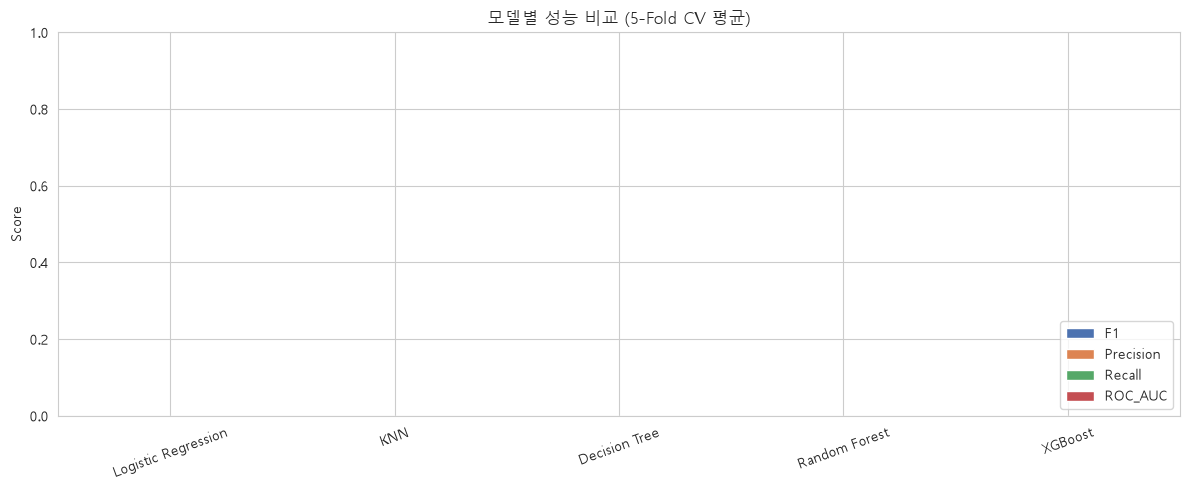

In [25]:
df_summary.plot(kind='bar', figsize=(12, 5), ylim=(0, 1),
                color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title('모델별 성능 비교 (5-Fold CV 평균)')
plt.xlabel('')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 결론

- 뇌졸중 데이터는 클래스 불균형(약 5%)이 심해서 Accuracy만으로 평가하면 의미가 없음
- SMOTE로 오버샘플링하면 Recall이 크게 올라감 (놓치면 안 되는 케이스이므로 Recall이 중요)
- Random Forest와 XGBoost가 단순 모델(KNN, 결정 트리)보다 전반적으로 성능이 좋음
- ROC-AUC 기준으로 최종 모델을 선택하는 게 불균형 데이터에서 더 합리적임